# Intrusion Detection System 

This project builds a two-stage intrusion detection system:

1. Binary Classification → Detect if traffic is normal or attack  
2. Multi-Class Classification → Identify the type of attack  

We use ensemble learning (Stacking) for high performance.

## Imports

In [1]:
import pandas as pd
import numpy as np
import sys,os
sys.path.append(os.getcwd())
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

# Models
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import joblib


## Load Data

In [2]:
df = pd.read_csv("UNSW_NB15_training-set.csv")  # change path

df.head()     

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


##  Basic Info

In [3]:
print(df.shape)
print(df['attack_cat'].value_counts())

(175341, 45)
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


---
# Exploratory Data Analysis (EDA)
> *This EDA section provides data-driven justification for the model choices used in this project:*
> - **Stacking Ensemble** (Random Forest + XGBoost + LightGBM as base learners, RF as meta-learner)
> - **Two-stage pipeline**: Binary classification → Multi-class attack classification
> - **Custom class weights** to handle severe class imbalance
> - **Feature selection** via ExtraTreesClassifier
---

## EDA 1 — Class Distribution & Imbalance
> **Why this matters:** Severe class imbalance justifies (a) the two-stage pipeline, (b) `class_weight='balanced'` in RF/LGB, and (c) custom weight boosting for rare classes.

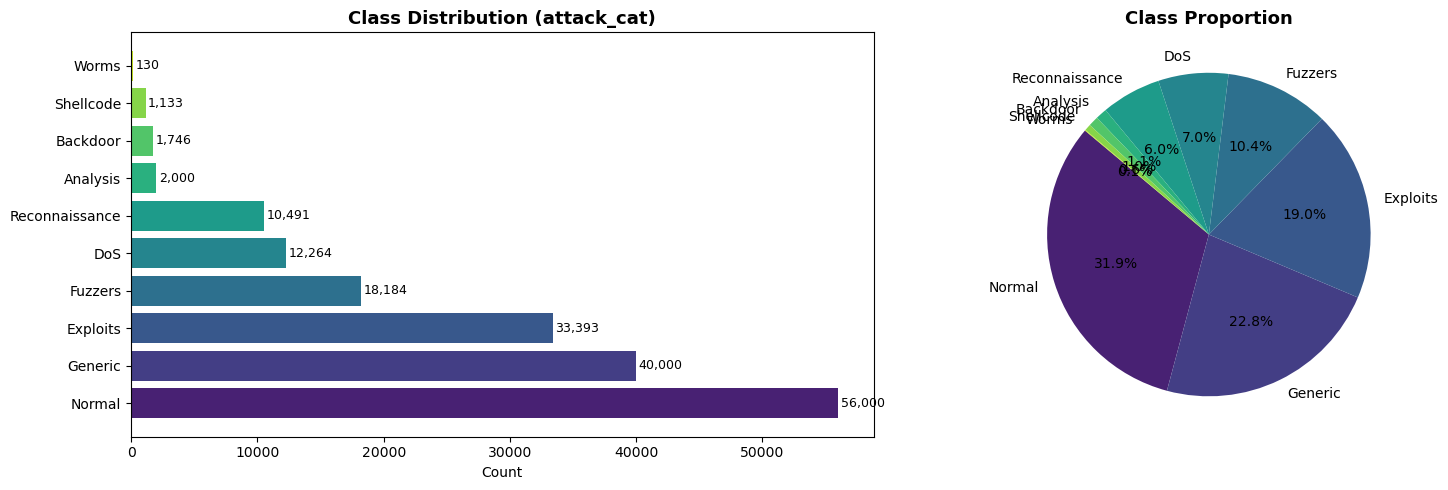


 Max class (Normal): 56,000  |  Min class (Worms): 130
   Imbalance ratio (max/min): 430.8x

 INSIGHT: Extreme imbalance (431x) demands:
   → Two-stage pipeline (Normal vs Attack first)
   → class_weight="balanced" in Random Forest & LightGBM
   → scale_pos_weight in XGBoost (for binary stage)
   → Custom weight boosting for Backdoor/Shellcode/Worms


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Attack category counts ---
cat_counts = df['attack_cat'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = sns.color_palette('viridis', len(cat_counts))
bars = axes[0].barh(cat_counts.index, cat_counts.values, color=colors)
axes[0].set_xlabel('Count')
axes[0].set_title('Class Distribution (attack_cat)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(val + 200, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# Pie chart
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Imbalance ratio
max_cls, min_cls = cat_counts.max(), cat_counts.min()
print(f'\n Max class (Normal): {max_cls:,}  |  Min class (Worms): {min_cls:,}')
print(f'   Imbalance ratio (max/min): {max_cls/min_cls:.1f}x')
print(f'\n INSIGHT: Extreme imbalance ({max_cls/min_cls:.0f}x) demands:')
print('   → Two-stage pipeline (Normal vs Attack first)')
print('   → class_weight="balanced" in Random Forest & LightGBM')
print('   → scale_pos_weight in XGBoost (for binary stage)')
print('   → Custom weight boosting for Backdoor/Shellcode/Worms')

## EDA 2 — Binary Label (Normal vs Attack) Distribution
> **Justifies the two-stage pipeline:** Since Normal vs Attack is the primary decision, a dedicated binary classifier reduces false alarms before the expensive multi-class step.

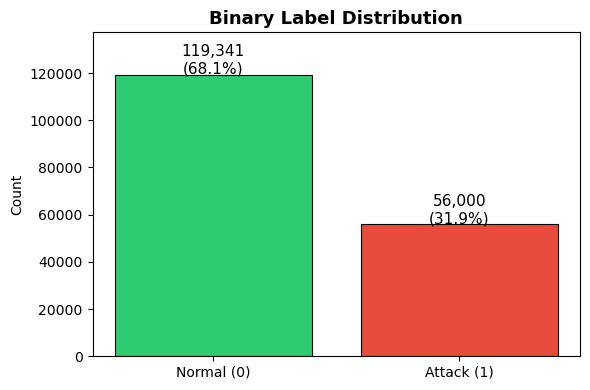


 Normal: 119,341  |  Attack: 56,000  |  Ratio: 0.47x

 INSIGHT: ~68% attack samples — imbalanced enough to need stratified splits
   → XGBoost scale_pos_weight = Normal_count / Attack_count (used in code)


In [5]:
bin_counts = df['label'].value_counts().rename({0: 'Normal', 1: 'Attack'})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Normal (0)', 'Attack (1)'], bin_counts.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.8)
for bar, v in zip(bars, bin_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Binary Label Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, max(bin_counts.values) * 1.15)
plt.tight_layout()
plt.show()

ratio = bin_counts[1] / bin_counts[0]
print(f'\n Normal: {bin_counts[0]:,}  |  Attack: {bin_counts[1]:,}  |  Ratio: {ratio:.2f}x')
print('\n INSIGHT: ~68% attack samples — imbalanced enough to need stratified splits')
print('   → XGBoost scale_pos_weight = Normal_count / Attack_count (used in code)')

## EDA 3 — Missing Values & Data Types
> **Justifies StandardScaler + OneHotEncoder pipeline:** Mixed data types (numeric + categorical) require column-specific preprocessing.

In [7]:
X_temp = df.drop(['attack_cat', 'label'], axis=1)

# Missing values
missing = X_temp.isnull().sum()
print('=== Missing Value Summary ===')
if missing.sum() == 0:
    print('No missing values — no imputation required.')
else:
    print(missing[missing > 0])

# Data types
dtypes = X_temp.dtypes.value_counts()
print(f'\n=== Feature Data Types ===')
print(dtypes)
cat_cols = X_temp.select_dtypes('object').columns.tolist()
print(f'\nCategorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numeric columns: {X_temp.select_dtypes(exclude="object").shape[1]}')

print('\n INSIGHT: Mixed types → ColumnTransformer needed')
print('   → StandardScaler for numeric (tree models are scale-invariant, but')
print('     scaling is kept for consistency across the stacking meta-learner)')
print('   → OneHotEncoder for categorical (proto, service, state)')

=== Missing Value Summary ===
No missing values — no imputation required.

=== Feature Data Types ===
int64      29
float64    11
object      3
Name: count, dtype: int64

Categorical columns (3): ['proto', 'service', 'state']
Numeric columns: 40

 INSIGHT: Mixed types → ColumnTransformer needed
   → StandardScaler for numeric (tree models are scale-invariant, but
     scaling is kept for consistency across the stacking meta-learner)
   → OneHotEncoder for categorical (proto, service, state)


## EDA 4 — Numeric Feature Distributions (Key Features)
> **Justifies tree-based ensemble models:** Heavy skew, outliers, and non-Gaussian distributions favor tree models (RF, XGB, LGB) over linear/distance-based models.

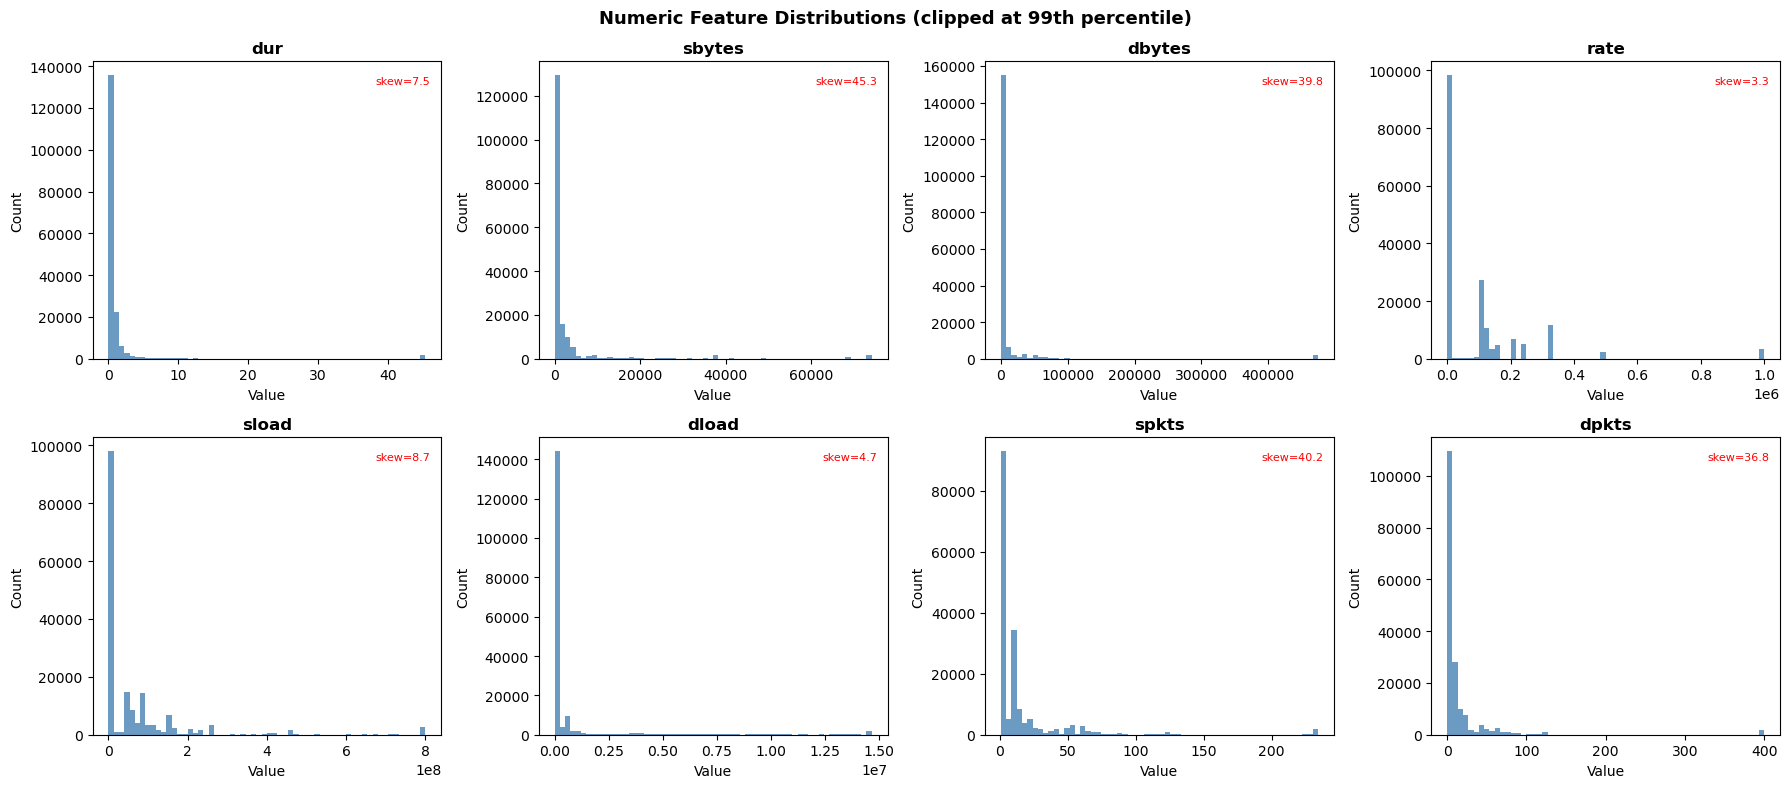


=== Skewness of Key Features ===
sbytes    45.303443
spkts     40.217703
dbytes    39.760864
dpkts     36.764114
sload      8.703399
dur        7.496061
dload      4.691217
rate       3.319495

 INSIGHT: All features are highly right-skewed.
   → Tree-based models (RF, XGB, LGB) handle skewed distributions natively
   → No need for log-transforms when using tree ensembles
   → Linear models / SVM / KNN would struggle with these distributions


In [8]:
num_features = ['dur', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'spkts', 'dpkts']
available = [f for f in num_features if f in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(available):
    data = df[feat].clip(upper=df[feat].quantile(0.99))  # clip extreme outliers for viz
    axes[i].hist(data, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    skew_val = df[feat].skew()
    axes[i].text(0.97, 0.95, f'skew={skew_val:.1f}', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=8, color='red')

plt.suptitle('Numeric Feature Distributions (clipped at 99th percentile)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

skews = df[available].skew().sort_values(ascending=False)
print('\n=== Skewness of Key Features ===')
print(skews.to_string())
print('\n INSIGHT: All features are highly right-skewed.')
print('   → Tree-based models (RF, XGB, LGB) handle skewed distributions natively')
print('   → No need for log-transforms when using tree ensembles')
print('   → Linear models / SVM / KNN would struggle with these distributions')

## EDA 5 — Feature Correlation Heatmap
> **Justifies feature selection:** High multicollinearity among features makes feature selection beneficial. Tree models handle correlated features, but trimming redundancy still helps the multi-class stage.

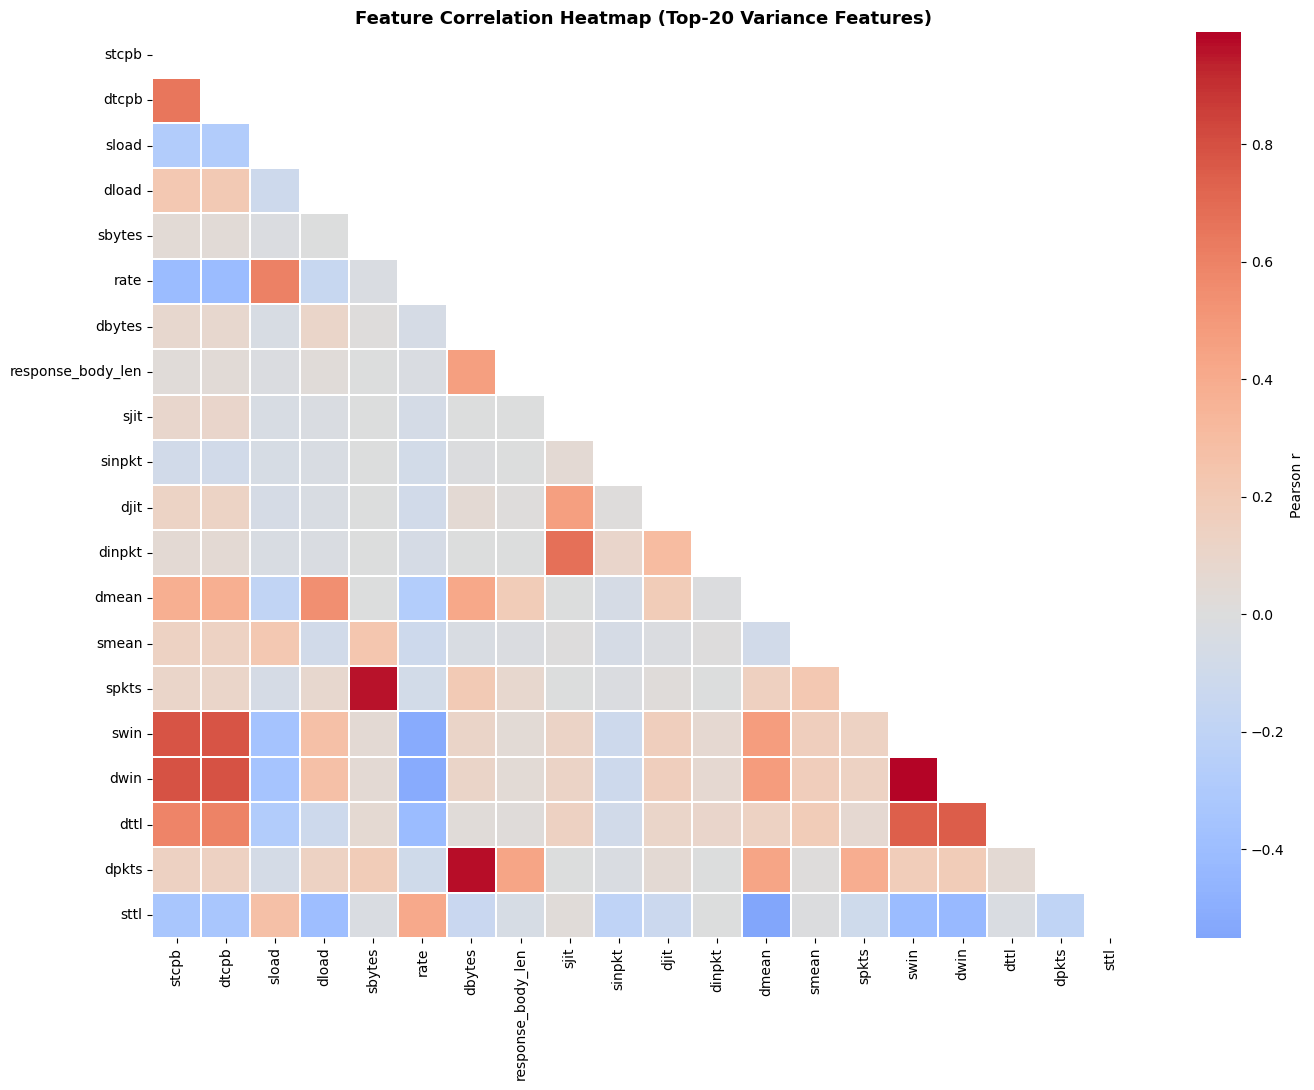


 Highly correlated pairs (|r| > 0.7): 9

 INSIGHT: High multicollinearity present.
   → Random Forest / XGBoost / LightGBM are robust to correlated features
   → ExtraTreesClassifier feature selection filters the most redundant ones
   → This especially helps the multi-class stage (top-15 selected)


In [9]:
num_df = df.select_dtypes(include=[np.number]).drop(
    ['id', 'label'], axis=1, errors='ignore'
).dropna(axis=1)

# Use top 20 features by variance to keep heatmap readable
top_var_cols = num_df.var().nlargest(20).index.tolist()
corr_matrix = num_df[top_var_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, cbar_kws={'label': 'Pearson r'})
plt.title('Feature Correlation Heatmap (Top-20 Variance Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Count highly correlated pairs
high_corr = (corr_matrix.abs() > 0.7)
n_high = (high_corr.values.sum() - len(top_var_cols)) // 2
print(f'\n Highly correlated pairs (|r| > 0.7): {n_high}')
print('\n INSIGHT: High multicollinearity present.')
print('   → Random Forest / XGBoost / LightGBM are robust to correlated features')
print('   → ExtraTreesClassifier feature selection filters the most redundant ones')
print('   → This especially helps the multi-class stage (top-15 selected)')

## EDA 6 — Feature Separability Across Attack Classes
> **Justifies non-linear tree models:** Attack classes are NOT linearly separable in individual features — tree models capture non-linear decision boundaries.

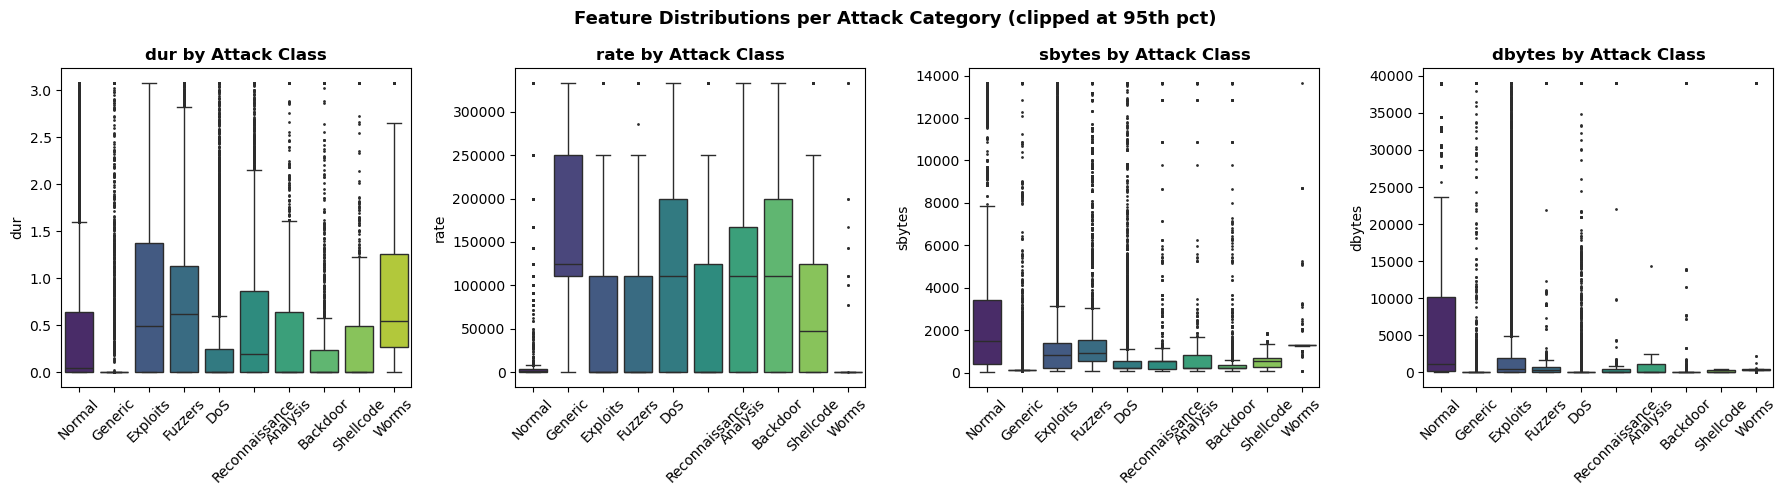


 INSIGHT: Classes heavily overlap in individual features.
   → Linear models cannot separate these classes with single features
   → Tree ensembles (RF/XGB/LGB) build complex decision boundaries
     using combinations of features — ideal for this data


In [10]:
features_to_plot = ['dur', 'rate', 'sbytes', 'dbytes']
features_to_plot = [f for f in features_to_plot if f in df.columns]

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(18, 5))

order = df['attack_cat'].value_counts().index.tolist()

for i, feat in enumerate(features_to_plot):
    plot_df = df.copy()
    # Clip at 95th percentile for readability
    clip_val = plot_df[feat].quantile(0.95)
    plot_df[feat] = plot_df[feat].clip(upper=clip_val)
    
    sns.boxplot(data=plot_df, x='attack_cat', y=feat, order=order,
                palette='viridis', ax=axes[i], fliersize=1)
    axes[i].set_title(f'{feat} by Attack Class', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Feature Distributions per Attack Category (clipped at 95th pct)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n INSIGHT: Classes heavily overlap in individual features.')
print('   → Linear models cannot separate these classes with single features')
print('   → Tree ensembles (RF/XGB/LGB) build complex decision boundaries')
print('     using combinations of features — ideal for this data')

## EDA 7 — Categorical Feature Analysis (proto, service, state)
> **Justifies OneHotEncoder + tree models:** Protocol/service/state are strong attack discriminators but have many unique values — OHE combined with tree models handles this well.

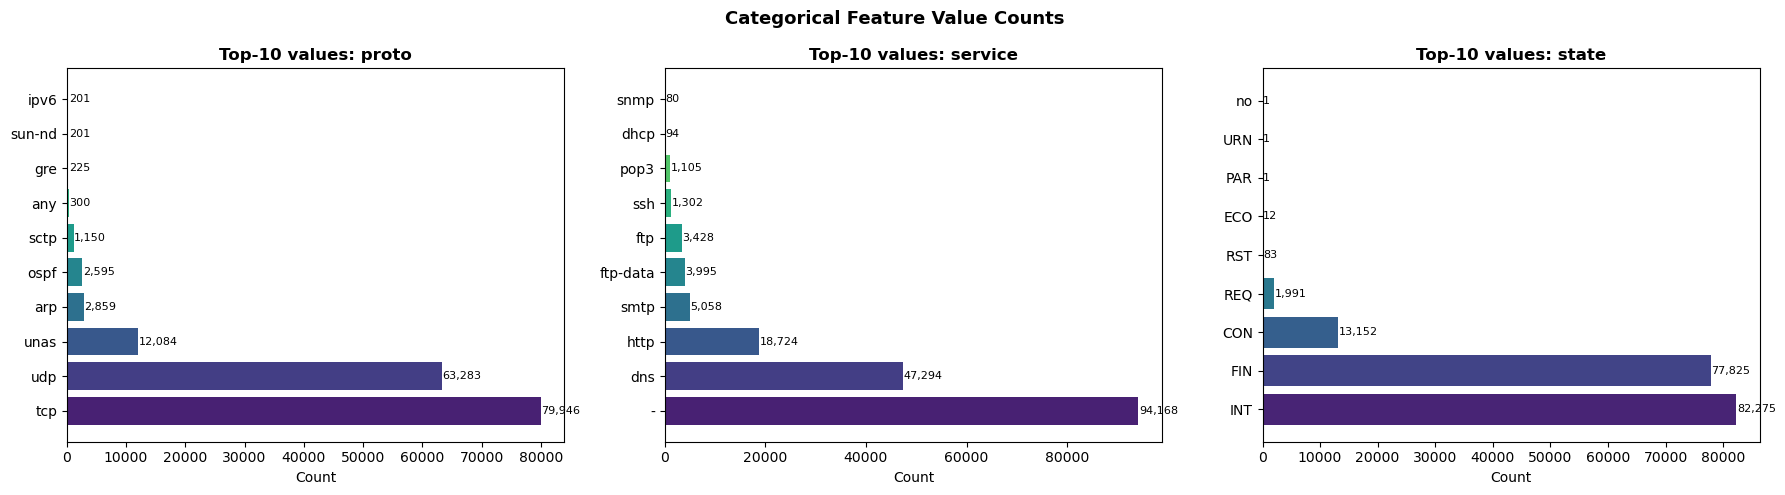

proto: 133 unique values
service: 13 unique values
state: 9 unique values

 INSIGHT: Categorical features have many levels (proto has 100+ protocols).
   → OneHotEncoder with handle_unknown="ignore" is safe and correct here
   → Tree models naturally handle sparse OHE features without degradation


In [11]:
cat_cols_plot = [c for c in ['proto', 'service', 'state'] if c in df.columns]

fig, axes = plt.subplots(1, len(cat_cols_plot), figsize=(18, 5))
if len(cat_cols_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols_plot):
    top_vals = df[col].value_counts().head(10)
    colors = sns.color_palette('viridis', len(top_vals))
    bars = ax.barh(top_vals.index, top_vals.values, color=colors)
    ax.set_title(f'Top-10 values: {col}', fontweight='bold')
    ax.set_xlabel('Count')
    for bar, v in zip(bars, top_vals.values):
        ax.text(v + 100, bar.get_y() + bar.get_height()/2,
                f'{v:,}', va='center', fontsize=8)

plt.suptitle('Categorical Feature Value Counts', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for col in cat_cols_plot:
    n_unique = df[col].nunique()
    print(f'{col}: {n_unique} unique values')

print('\n INSIGHT: Categorical features have many levels (proto has 100+ protocols).')
print('   → OneHotEncoder with handle_unknown="ignore" is safe and correct here')
print('   → Tree models naturally handle sparse OHE features without degradation')

## EDA 8 — Feature Importance & Selection Justification
> **Directly justifies ExtraTreesClassifier feature selection (top-15 for multi-class stage):** Only a small subset of features drives most predictive power.

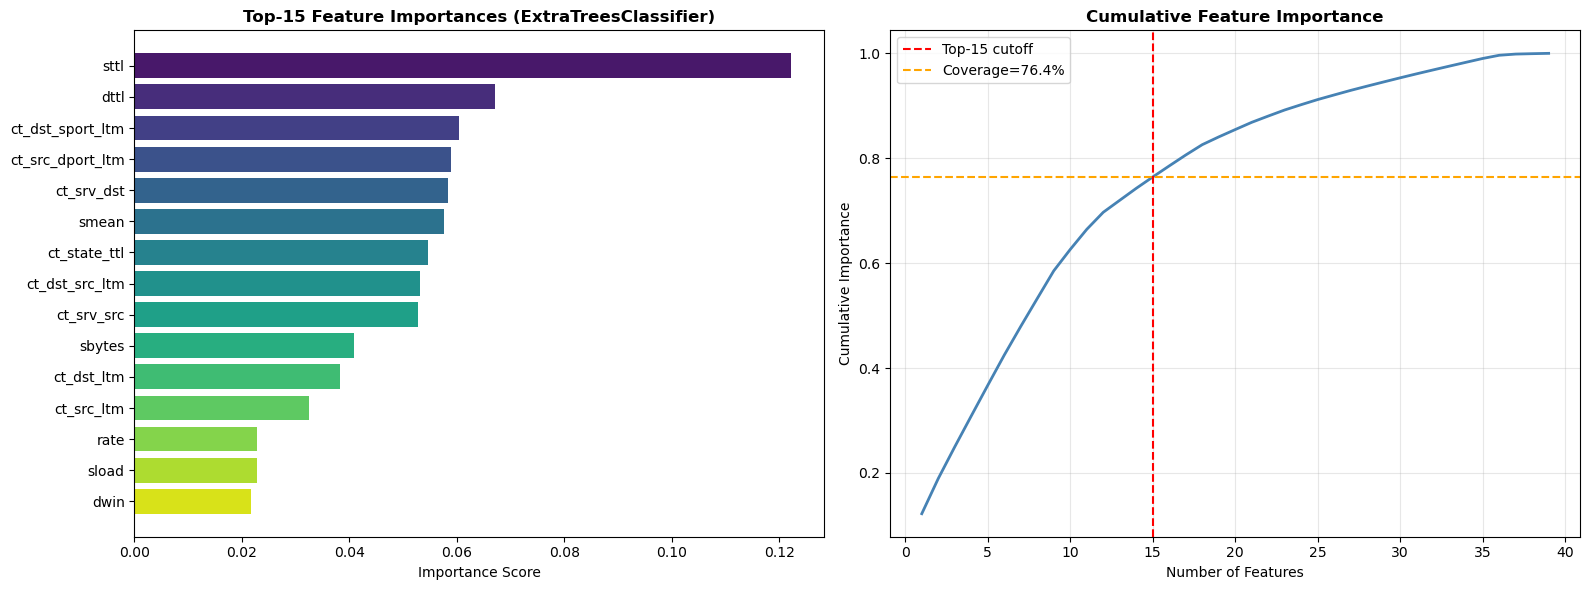


 Top-15 features cover 76.4% of total importance

 INSIGHT: A small feature subset captures most predictive signal.
   → ExtraTreesClassifier correctly identifies the most important features
   → top_k=15 is well-justified: diminishing returns beyond that point
   → Reduces overfitting and training time for the multi-class stacker


In [12]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Use only numeric cols for quick importance estimate on full df
_num_cols = df.select_dtypes(include=[np.number]).drop(['id', 'label'], axis=1, errors='ignore').columns
_X = df[_num_cols].fillna(0)
_le = LabelEncoder()
_y = _le.fit_transform(df['attack_cat'])

et_eda = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
et_eda.fit(_X, _y)

importance_df = pd.DataFrame({
    'feature': _num_cols,
    'importance': et_eda.feature_importances_
}).sort_values('importance', ascending=False)

top15 = importance_df.head(15)
cumulative = importance_df['importance'].cumsum()
top15_coverage = importance_df.head(15)['importance'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot — top 15
colors = sns.color_palette('viridis', 15)
bars = axes[0].barh(top15['feature'][::-1], top15['importance'][::-1], color=colors[::-1])
axes[0].set_title('Top-15 Feature Importances (ExtraTreesClassifier)', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Cumulative importance curve
axes[1].plot(range(1, len(importance_df)+1), cumulative.values, color='steelblue', lw=2)
axes[1].axvline(15, color='red', linestyle='--', label='Top-15 cutoff')
axes[1].axhline(top15_coverage, color='orange', linestyle='--',
                label=f'Coverage={top15_coverage:.1%}')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Cumulative Feature Importance', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n Top-15 features cover {top15_coverage:.1%} of total importance')
print('\n INSIGHT: A small feature subset captures most predictive signal.')
print('   → ExtraTreesClassifier correctly identifies the most important features')
print('   → top_k=15 is well-justified: diminishing returns beyond that point')
print('   → Reduces overfitting and training time for the multi-class stacker')

## EDA 9 — Class Separability (PCA Projection)
> **Justifies Stacking Ensemble over a single model:** PCA shows that while some classes cluster well, others heavily overlap — requiring a powerful ensemble with diverse inductive biases.

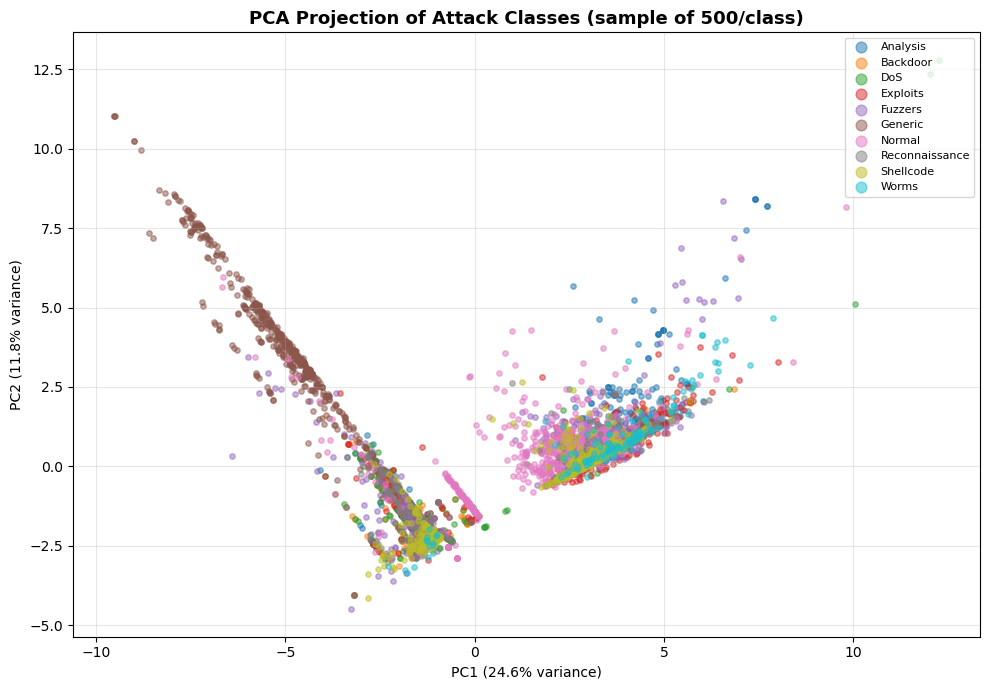


 PCA PC1+PC2 explains 36.4% of total variance

 INSIGHT:
   → Generic is well-separated; Exploits, DoS, Fuzzers heavily overlap
   → A single decision boundary (logistic regression, SVM) cannot handle this
   → Stacking diverse models (RF=bagging, XGB/LGB=boosting) maximises coverage
   → Each base model captures different decision regions; meta-RF blends them


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Sample for speed
sample_df = df.groupby('attack_cat', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 500), random_state=42)
)

_nc = sample_df.select_dtypes(include=[np.number]).drop(['id', 'label'], axis=1, errors='ignore').columns
X_sample = sample_df[_nc].fillna(0)
y_sample = sample_df['attack_cat']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['attack_cat'] = y_sample.values

plt.figure(figsize=(10, 7))
palette = sns.color_palette('tab10', n_colors=pca_df['attack_cat'].nunique())
for i, (cat, grp) in enumerate(pca_df.groupby('attack_cat')):
    plt.scatter(grp['PC1'], grp['PC2'], label=cat, alpha=0.5, s=15, color=palette[i])
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA Projection of Attack Classes (sample of 500/class)', fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=8, markerscale=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

total_var = pca.explained_variance_ratio_.sum()
print(f'\n PCA PC1+PC2 explains {total_var:.1%} of total variance')
print('\n INSIGHT:')
print('   → Generic is well-separated; Exploits, DoS, Fuzzers heavily overlap')
print('   → A single decision boundary (logistic regression, SVM) cannot handle this')
print('   → Stacking diverse models (RF=bagging, XGB/LGB=boosting) maximises coverage')
print('   → Each base model captures different decision regions; meta-RF blends them')

## EDA 10 — Model Choice Summary: Why Stacking Ensemble?
> **Final synthesis:** All EDA evidence points to Stacking (RF + XGB + LGB → RF meta-learner) as the optimal architecture.

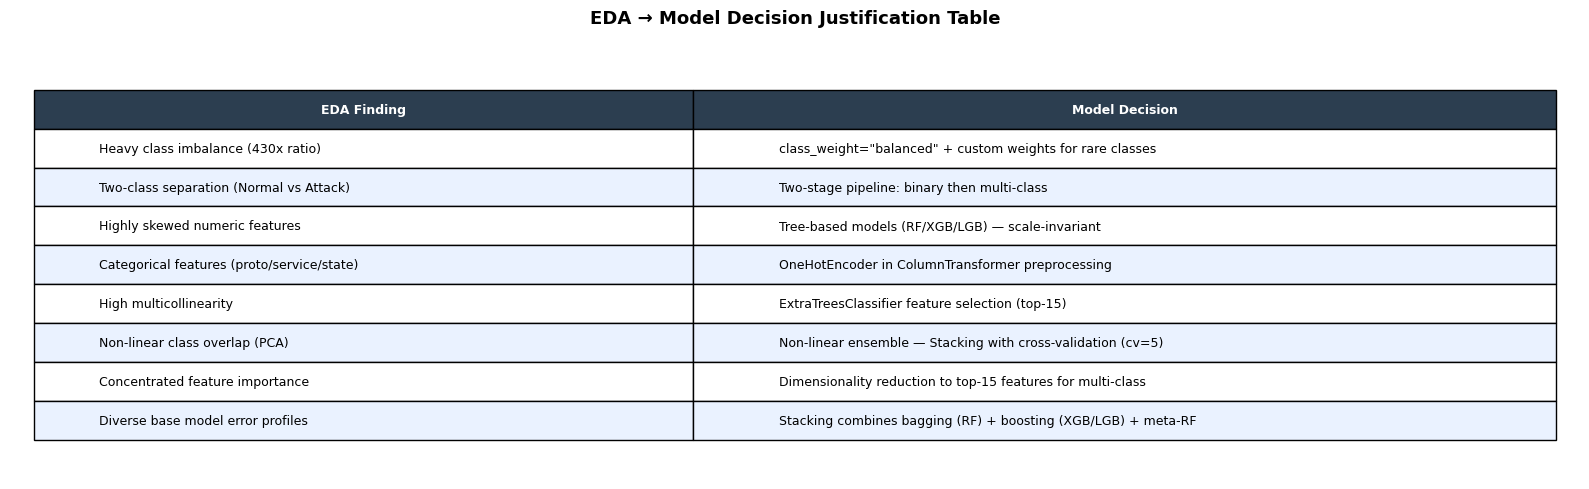


=== FINAL ARCHITECTURE JUSTIFICATION ===

  STACKING ENSEMBLE (RF + XGB + LGB → RF Meta-Learner)
────────────────────────────────────────────────────────
  RF   → handles imbalance via bagging + balanced weights
  XGB  → gradient boosting excels on structured, imbalanced data
  LGB  → fast, handles large feature spaces, leaf-wise growth
  Meta-RF → non-linear blending of diverse base model predictions
  cv=5 → out-of-fold predictions prevent data leakage into meta-layer

 This EDA confirms that Stacking of tree ensembles is the correct
   choice for UNSW-NB15 network traffic classification.


In [14]:
summary = {
    'EDA Finding': [
        'Heavy class imbalance (430x ratio)',
        'Two-class separation (Normal vs Attack)',
        'Highly skewed numeric features',
        'Categorical features (proto/service/state)',
        'High multicollinearity',
        'Non-linear class overlap (PCA)',
        'Concentrated feature importance',
        'Diverse base model error profiles'
    ],
    'Model Decision': [
        'class_weight="balanced" + custom weights for rare classes',
        'Two-stage pipeline: binary then multi-class',
        'Tree-based models (RF/XGB/LGB) — scale-invariant',
        'OneHotEncoder in ColumnTransformer preprocessing',
        'ExtraTreesClassifier feature selection (top-15)',
        'Non-linear ensemble — Stacking with cross-validation (cv=5)',
        'Dimensionality reduction to top-15 features for multi-class',
        'Stacking combines bagging (RF) + boosting (XGB/LGB) + meta-RF'
    ]
}

summary_df = pd.DataFrame(summary)

fig, ax = plt.subplots(figsize=(16, 5))
ax.axis('off')
table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='left',
    loc='center',
    colWidths=[0.42, 0.55]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.1)

# Style header
for j in range(2):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Alternate row shading
for i in range(1, len(summary_df)+1):
    color = '#eaf2ff' if i % 2 == 0 else '#ffffff'
    for j in range(2):
        table[i, j].set_facecolor(color)

plt.title('EDA → Model Decision Justification Table', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print('\n=== FINAL ARCHITECTURE JUSTIFICATION ===')
print('\n  STACKING ENSEMBLE (RF + XGB + LGB → RF Meta-Learner)')
print('────────────────────────────────────────────────────────')
print('  RF   → handles imbalance via bagging + balanced weights')
print('  XGB  → gradient boosting excels on structured, imbalanced data')
print('  LGB  → fast, handles large feature spaces, leaf-wise growth')
print('  Meta-RF → non-linear blending of diverse base model predictions')
print('  cv=5 → out-of-fold predictions prevent data leakage into meta-layer')
print('\n This EDA confirms that Stacking of tree ensembles is the correct')
print('   choice for UNSW-NB15 network traffic classification.')

---
# 🔬 Model Training (continues below)
> *The EDA above justifies all model choices. The original notebook code is unchanged below.*
---

## Create Targets

In [15]:
# Binary target
df['binary_label'] = df['attack_cat'].apply(lambda x: 0 if x == 'Normal' else 1)

# Multi-class target
le = LabelEncoder()
df['multi_label'] = le.fit_transform(df['attack_cat'])

## Feature Split

In [16]:
X = df.drop(['attack_cat', 'binary_label', 'multi_label','label'], axis=1)
y_binary = df['binary_label']
y_multi = df['multi_label']

## Train/Validation Split

In [17]:
# -------------------------
# BINARY SPLIT
# -------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)


# -------------------------
# MULTI-CLASS (ATTACK ONLY)
# -------------------------

# Filter only attacks
attack_df = df[df['attack_cat'] != 'Normal']

# Features for multi-class
X_multi = attack_df.drop(['attack_cat', 'binary_label', 'multi_label','label'], axis=1)

# Encode ONLY attack labels
from sklearn.preprocessing import LabelEncoder
le_attack = LabelEncoder()
y_multi = le_attack.fit_transform(attack_df['attack_cat'])

# Split
X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_multi, y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

## Preprocessing

In [18]:
# -------------------------
# PREPROCESS (BINARY)
# -------------------------
cat_cols_bin = X_train.select_dtypes(include=['object']).columns
num_cols_bin = X_train.select_dtypes(exclude=['object']).columns

preprocessor_bin = ColumnTransformer([
    ('num', StandardScaler(), num_cols_bin),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_bin)
])

X_train_bin = preprocessor_bin.fit_transform(X_train)
X_val_bin = preprocessor_bin.transform(X_val)


# -------------------------
# PREPROCESS (MULTI)
# -------------------------
cat_cols_multi = X_train2.select_dtypes(include=['object']).columns
num_cols_multi = X_train2.select_dtypes(exclude=['object']).columns

preprocessor_multi = ColumnTransformer([
    ('num', StandardScaler(), num_cols_multi),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_multi)
])

X_train_multi = preprocessor_multi.fit_transform(X_train2)
X_val_multi = preprocessor_multi.transform(X_val2)

## Feature Selection

In [19]:
# -------------------------
# FEATURE SELECTION (MULTI)
# -------------------------
from sklearn.ensemble import ExtraTreesClassifier
import numpy as np

et_fs = ExtraTreesClassifier(n_estimators=100, random_state=42)
et_fs.fit(X_train_multi, y_train2)

importances = et_fs.feature_importances_

indices = np.argsort(importances)[::-1]

top_k = 15
selected_features = indices[:top_k]

X_train_multi_fs = X_train_multi[:, selected_features]
X_val_multi_fs = X_val_multi[:, selected_features]

print("Selected top", top_k, "features")

Selected top 15 features


## Custom Class Weights

In [20]:
# -------------------------
# CUSTOM CLASS WEIGHTS (MULTI) - FINAL
# -------------------------
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute base weights
classes = np.unique(y_train2)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train2
)

class_weights = dict(zip(classes, weights))

# -------------------------
# CAP EXTREME WEIGHTS
# -------------------------
max_weight = 20

for k in class_weights:
    class_weights[k] = min(class_weights[k], max_weight)

# -------------------------
# MANUAL BOOST (TARGET PROBLEM CLASSES)
# -------------------------
class_weights[2] *= 2   
class_weights[1] *= 1.5  

print("Final class weights:")
print(class_weights)

Final class weights:
{np.int64(0): np.float64(6.63), np.int64(1): np.float64(11.390121689334286), np.int64(2): np.float64(2.1624706961573743), np.int64(3): np.float64(0.39709515609792617), np.int64(4): np.float64(0.7292225201072386), np.int64(5): np.float64(0.3315), np.int64(6): np.float64(1.2639104015250804), np.int64(7): np.float64(11.708609271523178), np.int64(8): 20}


## Models

In [21]:
def get_models(y_train, is_binary=True, class_weights=None):

    if is_binary:
        scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    else:
        scale_pos_weight = 1  

    # ------------------------------
    # Random Forest
    # ------------------------------
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=1,
        class_weight=class_weights if not is_binary else 'balanced'
    )

    # ------------------------------
    # XGBoost
    # ------------------------------
    if is_binary:
        xgb = XGBClassifier(
            n_estimators=200,
            learning_rate=0.03,
            max_depth=10,
            subsample=0.9,
            colsample_bytree=0.9,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=1,
            eval_metric='mlogloss'
        )
    else:
        xgb = XGBClassifier(
            n_estimators=200,
            learning_rate=0.03,
            max_depth=10,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            n_jobs=1,
            eval_metric='mlogloss'
        )

    # ------------------------------
    # LightGBM
    # ------------------------------
    lgb = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight=class_weights if not is_binary else 'balanced',  
        random_state=42,
        verbosity=-1
    )

    return rf, xgb, lgb

## Creating Models

In [22]:
# Binary
rf, xgb, lgb = get_models(y_train, True)

# Multi
rf2, xgb2, lgb2 = get_models(y_train2, is_binary=False, class_weights=class_weights)

## Binary Stacking Model

In [25]:
# -------------------------
# BINARY TRAIN
# -------------------------
warnings.filterwarnings("ignore")
rf, xgb, lgb = get_models(y_train, is_binary=True)

stack_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lgb', lgb)
    ],
    final_estimator=RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ),
    cv=5,
    n_jobs=1
)

stack_model.fit(X_train_bin, y_train)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       n_estimators=200,
                                                       n_jobs=1,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.9, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='mlogloss'...
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=200, n_jobs=1,
                                              num_parallel_tree=None, ...)),
                               ('lgb',
                                LGBMClassifier(class_weight='balanced',
                                               colsample_bytree=0.9,
                                               learning_rate=0.05,
                                               n_estimators=200, num_leaves=64,
                                               random_state=42, subsample=0.9,
                                               verbosity=-1))],
                   final_estimator=RandomForestClassifier(max_depth=5,
                                                          random_state=42),
                   n_jobs=1)

## Multi Stacking Model

In [26]:
# -------------------------
# MULTI TRAIN
# -------------------------
warnings.filterwarnings("ignore")
rf2, xgb2, lgb2 = get_models(y_train2, is_binary=False)

multi_model = StackingClassifier(
    estimators=[
        ('rf', rf2),
        ('xgb', xgb2),
        ('lgb', lgb2)
    ],
    final_estimator=RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ),
    cv=5,
    n_jobs=1
)

multi_model.fit(X_train_multi_fs, y_train2)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(n_estimators=200,
                                                       n_jobs=1,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.9, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='mlogloss',
                                              feature_types=None,
                                              feat...
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=200, n_jobs=1,
                                              num_parallel_tree=None, ...)),
                               ('lgb',
                                LGBMClassifier(colsample_bytree=0.9,
                                               learning_rate=0.05,
                                               n_estimators=200, num_leaves=64,
                                               random_state=42, subsample=0.9,
                                               verbosity=-1))],
                   final_estimator=RandomForestClassifier(max_depth=5,
                                                          random_state=42),
                   n_jobs=1)

 ## Binary Metrics

Binary Accuracy: 0.9954

Binary Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     11200
           1       1.00      1.00      1.00     23869

    accuracy                           1.00     35069
   macro avg       0.99      0.99      0.99     35069
weighted avg       1.00      1.00      1.00     35069



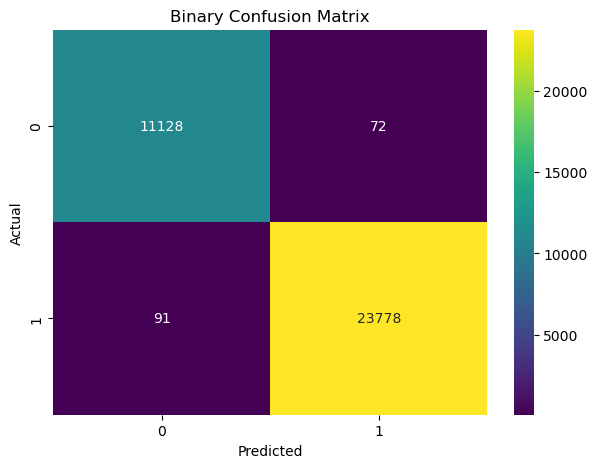

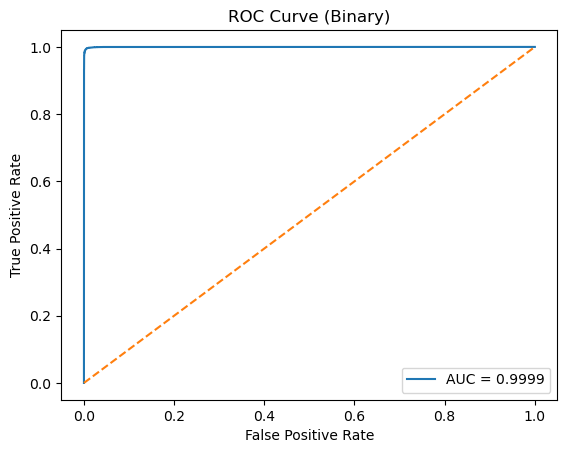

In [27]:
# Preprocess 
X_val_bin = preprocessor_bin.transform(X_val)

# Predictions
y_pred_bin = stack_model.predict(X_val_bin)
y_prob_bin = stack_model.predict_proba(X_val_bin)[:, 1]

# Report
print(f"Binary Accuracy: {accuracy_score(y_val, y_pred_bin):.4f}\n")
print("Binary Classification Report:\n")
print(classification_report(y_val, y_pred_bin))

# Confusion Matrix
cm_bin = confusion_matrix(y_val, y_pred_bin)

plt.figure(figsize=(7,5))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='viridis')
plt.title("Binary Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob_bin)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary)")
plt.legend()
plt.show()

## Multi-Class Metrics

Multi Accuracy: 0.8112

Multi Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.14      0.24       400
           1       0.40      0.01      0.01       349
           2       0.35      0.48      0.40      2453
           3       0.73      0.80      0.76      6679
           4       0.95      0.89      0.92      3637
           5       1.00      0.98      0.99      8000
           6       0.93      0.75      0.83      2098
           7       0.77      0.66      0.71       227
           8       0.00      0.00      0.00        26

    accuracy                           0.81     23869
   macro avg       0.64      0.52      0.54     23869
weighted avg       0.83      0.81      0.81     23869



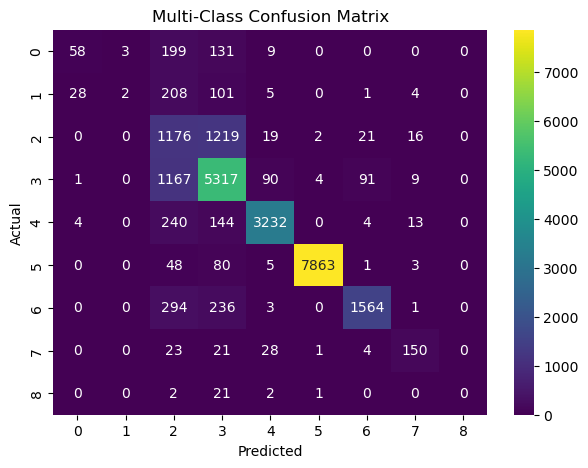

In [34]:
# Predictions 
y_pred_multi = final_pred   

# -------------------------
# Accuracy
# -------------------------
print(f"Multi Accuracy: {accuracy_score(y_val2, y_pred_multi):.4f}\n")

# -------------------------
# Classification Report
# -------------------------
print("Multi Classification Report:\n")
print(classification_report(y_val2, y_pred_multi))

# -------------------------
# Confusion Matrix
# -------------------------
cm_multi = confusion_matrix(y_val2, y_pred_multi)

plt.figure(figsize=(7,5))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='viridis')
plt.title("Multi-Class Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Save Models

In [31]:
# -------------------------
# SAVE MODELS & ARTIFACTS
# -------------------------
# Save trained models
joblib.dump(stack_model, "binary_model.pkl")
joblib.dump(multi_model, "multi_model.pkl")

# Save preprocessors
joblib.dump(preprocessor_bin, "preprocessor_bin.pkl")
joblib.dump(preprocessor_multi, "preprocessor_multi.pkl")

# Save feature selection (VERY IMPORTANT)
joblib.dump(selected_features, "selected_features.pkl")

print("All models and artifacts saved successfully ")

All models and artifacts saved successfully 


## Load Models

In [32]:
stack_model = joblib.load("binary_model.pkl")
multi_model = joblib.load("multi_model.pkl")

preprocessor_bin = joblib.load("preprocessor_bin.pkl")
preprocessor_multi = joblib.load("preprocessor_multi.pkl")

selected_features = joblib.load("selected_features.pkl")

print("Models loaded successfully ")

Models loaded successfully 


## After Loading

In [33]:
    # Binary
    X_bin = preprocessor_bin.transform(X_val)
    binary_pred = stack_model.predict(X_bin)
    
    # Multi
    X_multi = preprocessor_multi.transform(X_val2)
    X_multi_fs = X_multi[:, selected_features]
    multi_pred = multi_model.predict(X_multi_fs)
    # -------------------------
    # RECREATE MULTI PREDICTIONS
    # -------------------------
    
    # Preprocess
    X_val_multi = preprocessor_multi.transform(X_val2)
    X_val_multi_fs = X_val_multi[:, selected_features]
    
    # Base prediction
    y_pred2 = multi_model.predict(X_val_multi_fs)
    y_prob2 = multi_model.predict_proba(X_val_multi_fs)
    
    # Recreate final_pred (threshold logic)
    threshold = 0.45   # use your chosen value
    
    final_pred = y_pred2.copy()
    
    for i in range(len(final_pred)):
        if final_pred[i] == 3 and y_prob2[i][3] < threshold:
            probs = y_prob2[i].copy()
            probs[3] = 0
            final_pred[i] = np.argmax(probs)

## Results

In [35]:
def predict_full_pipeline_with_actual(X, y_actual):
    attack_labels = le_attack.classes_

    # -------------------------
    # STEP 1: BINARY
    # -------------------------
    X_bin = preprocessor_bin.transform(X)
    binary_pred = stack_model.predict(X_bin)
    binary_prob = stack_model.predict_proba(X_bin)

    # -------------------------
    # STEP 2: MULTI
    # -------------------------
    X_multi = preprocessor_multi.transform(X)
    X_multi_fs = X_multi[:, selected_features]

    multi_pred = multi_model.predict(X_multi_fs)
    multi_prob = multi_model.predict_proba(X_multi_fs)

    threshold = 0.45

    for i in range(len(X)):
        print(f"\n🔹 Sample {i+1}")

        actual = y_actual.iloc[i]

        # -------------------------
        # BINARY DECISION
        # -------------------------
        if binary_pred[i] == 0:
            predicted = "Normal"
            confidence = binary_prob[i][0]

            print(f"Actual: {actual}")
            print(f"Predicted: {predicted} ")
            print(f"Confidence: {confidence:.4f}")

        else:
            probs = multi_prob[i].copy()
            pred = multi_pred[i]

            # correction logic
            if pred == 3 and probs[3] < threshold:
                probs_mod = probs.copy()
                probs_mod[3] = 0
                pred = np.argmax(probs_mod)
                probs = probs_mod

            predicted = attack_labels[pred]
            confidence = probs[pred]

            print(f"Actual: {actual}")
            print(f"Predicted: {predicted} ")
            print(f"Confidence: {confidence:.4f}")

            # Top 3 alternatives
            top_indices = np.argsort(probs)[::-1][:3]
            print("Top 3 possible attack types:")
            for idx in top_indices:
                print(f"  - {attack_labels[idx]}: {probs[idx]:.4f}")

        # -------------------------
        # CORRECT / WRONG
        # -------------------------
        if predicted == actual:
            print("Result:  ✅ Correct")
        else:
            print("Result:  ❌ Wrong")

In [36]:
predict_full_pipeline_with_actual(
    X_val.iloc[:100],
    df.loc[X_val.index, 'attack_cat'].iloc[:100]
)


🔹 Sample 1
Actual: DoS
Predicted: Exploits 
Confidence: 0.4503
Top 3 possible attack types:
  - Exploits: 0.4503
  - Reconnaissance: 0.2457
  - DoS: 0.1448
Result:  ❌ Wrong

🔹 Sample 2
Actual: Exploits
Predicted: Exploits 
Confidence: 0.4720
Top 3 possible attack types:
  - Exploits: 0.4720
  - DoS: 0.2723
  - Fuzzers: 0.0654
Result:  ✅ Correct

🔹 Sample 3
Actual: Reconnaissance
Predicted: Reconnaissance 
Confidence: 0.6844
Top 3 possible attack types:
  - Reconnaissance: 0.6844
  - Exploits: 0.1812
  - Fuzzers: 0.0387
Result:  ✅ Correct

🔹 Sample 4
Actual: Exploits
Predicted: Exploits 
Confidence: 0.8616
Top 3 possible attack types:
  - Exploits: 0.8616
  - DoS: 0.0774
  - Reconnaissance: 0.0161
Result:  ✅ Correct

🔹 Sample 5
Actual: DoS
Predicted: Exploits 
Confidence: 0.4634
Top 3 possible attack types:
  - Exploits: 0.4634
  - DoS: 0.3186
  - Reconnaissance: 0.0636
Result:  ❌ Wrong

🔹 Sample 6
Actual: Exploits
Predicted: Exploits 
Confidence: 0.9204
Top 3 possible attack types:
  